<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/ASP/02TWM_demo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Demo2 on Two Way Mismatch and further

[TWM with Matrix Representation](https://github.com/Kohei-200/math/blob/main/ASP/YIN_TWMwithMatrix.ipynb) turned out to be visually comprehensible.

In [1]:
# audio sample
!git clone https://github.com/MTG/sms-tools-materials.git

fatal: destination path 'sms-tools-materials' already exists and is not an empty directory.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import soundfile as sf
import scipy
import scipy.fft as fft
from scipy import signal

#### Two-pass search on candidates

pass 1 search the entire range using 1-semitone steps

pass 2 take the note from pass 1 to focus on, to make it resolute.

In [3]:
import numpy as np

def estimate_f0_twm_errors(f_k, A_k, candidates, nH = 10, p=0.5, q=1.4, r=0.5, rho=0.33):
    """Estimates fundamental frequency (f0) using the Two-Way Mismatch algorithm."""

    A_max = np.max(A_k)
    nH = np.arange(1, nH + 1)

    # (Candidates x Harmonics x Peaks)
    f_r = candidates[:, np.newaxis] * nH
    all_distances = np.abs(f_r[:, :, np.newaxis] - f_k)

    # P -> M Error
    delta_fr = np.min(all_distances, axis=2)
    closest_indices_pm = np.argmin(all_distances, axis=2)
    a_n = A_k[closest_indices_pm]

    err_pm_matrix = delta_fr * (f_r**-p) + (a_n / A_max) * (q * delta_fr * (f_r**-p) - r)
    total_err_pm = np.sum(err_pm_matrix, axis=1)

    # M -> P Error
    delta_fk = np.min(all_distances, axis=1)
    # NumPy broadcasts f_k and A_k perfectly across the 2D matrix
    err_mp_matrix = delta_fk * (f_k**-p) + (A_k / A_max) * (q * delta_fk * (f_k**-p) - r)
    total_err_mp = np.sum(err_mp_matrix, axis=1)

    # Total Error & Winning f0
    N = len(nH)
    K = len(f_k)

    Err_total = (total_err_pm / N) + rho * (total_err_mp / K)

    return Err_total

def estimate_f0_twm(f_k, A_k, candidates, **kwargs):
    """Convenience wrapper — just returns the best f0."""
    Err_total = estimate_f0_twm_errors(f_k, A_k, candidates, **kwargs)
    best_f0 = candidates[np.argmin(Err_total)]
    return best_f0


In [4]:
path =  "/content/sms-tools-materials/sounds/piano.wav"
x, sr = sf.read(path)

MIN_MIDI = 36.0
MAX_MIDI = 84.0
semitone = 1
midi = np.arange(MIN_MIDI, MAX_MIDI, semitone)

M = 1024
f, t, Zxx = signal.stft(x, fs=sr, nperseg=M)
Zxx_mag = np.abs(Zxx) # convert complex data to amplitude

pitch_contour = []

global_peak = np.max(Zxx_mag)
noise_floor = 0.01 * global_peak

prev_f0 = 0.0

pass1_candidates = 440.0 * (2.0 ** ((midi - 69.0) / 12.0))


nH = 10

max_f0 = (sr / 2) / 4   # at least 3 harmonics must fit below threshhold
pass1_candidates = pass1_candidates[pass1_candidates < max_f0]

for i in range(len(t)):
    current_frame = Zxx_mag[:, i]

    if np.max(current_frame) < noise_floor:
        pitch_contour.append(0.0)
        continue

    peak_indices, props = signal.find_peaks(
    current_frame,
    height=noise_floor,
    prominence=0.02* global_peak  # only prominent peaks
)
    f_k = f[peak_indices]
    A_k = props["peak_heights"]

    mask = (f_k > 50) & (f_k < 4000)
    f_k, A_k = f_k[mask], A_k[mask]

    if len(f_k) <= 2:
        pitch_contour.append(0.0)
        continue
    # Cndidate filtering
    lowest_peak = f_k[np.argmax(A_k[:3])]
    max_f0 = lowest_peak
    min_f0 = lowest_peak / nH
    cand_mask = (pass1_candidates >= min_f0) & (pass1_candidates <= max_f0)
    valid_candidates = pass1_candidates[cand_mask]
    if len(valid_candidates) == 0:
        valid_candidates = pass1_candidates


    # pass 1
    pass1_f0 = estimate_f0_twm(f_k, A_k, valid_candidates, nH=nH)

    rough_midi = 12.0 * np.log2(pass1_f0 / 440.0) + 69.0

    # pass 2
    pass2_midi = np.arange(rough_midi - 1.0, rough_midi + 1.0, 0.05)
    pass2_candidates = 440.0 * (2.0 ** ((pass2_midi - 69.0) / 12.0))

    Err_total = estimate_f0_twm_errors(f_k, A_k, pass2_candidates)


    # continuity penalty
    if prev_f0 > 0:
        continuity_penalty = 0.1 * np.abs(np.log2(pass2_candidates / prev_f0))
        Err_total += continuity_penalty

    final_f0 = pass2_candidates[np.argmin(Err_total)]
    prev_f0 = final_f0
    pitch_contour.append(final_f0)


pitch_contour = np.array(pitch_contour)

In [5]:
pass1_candidates

array([ 65.40639133,  69.29565774,  73.41619198,  77.78174593,
        82.40688923,  87.30705786,  92.49860568,  97.998859  ,
       103.82617439, 110.        , 116.54094038, 123.47082531,
       130.81278265, 138.59131549, 146.83238396, 155.56349186,
       164.81377846, 174.61411572, 184.99721136, 195.99771799,
       207.65234879, 220.        , 233.08188076, 246.94165063,
       261.6255653 , 277.18263098, 293.66476792, 311.12698372,
       329.62755691, 349.22823143, 369.99442271, 391.99543598,
       415.30469758, 440.        , 466.16376152, 493.88330126,
       523.2511306 , 554.36526195, 587.32953583, 622.25396744,
       659.25511383, 698.45646287, 739.98884542, 783.99087196,
       830.60939516, 880.        , 932.32752304, 987.76660251])

/tmp/ipykernel_31921/156320307.py:4: RuntimeWarning: divide by zero encountered in log2
  log_contour = np.where(contour > 0, np.log2(contour), 0)


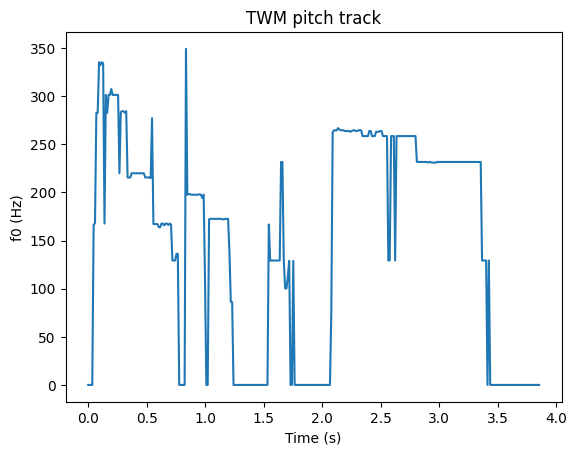

In [6]:
def octave_aware_smooth(contour, kernel_size=121):
    # Convert to log, median filter, convert back
    # prevent log(0) on silent frames
    log_contour = np.where(contour > 0, np.log2(contour), 0)
    smoothed_log = scipy.signal.medfilt(log_contour, kernel_size=kernel_size)
    return np.where(contour > 0, 2 ** smoothed_log, 0)

smoothed_pitch = octave_aware_smooth(pitch_contour, kernel_size=121)
times = t
plt.plot(times, pitch_contour)
plt.xlabel('Time (s)')
plt.ylabel('f0 (Hz)')
plt.title('TWM pitch track')
plt.show()

In [7]:
frame_times = t

total_samples = len(x)
sample_times = np.arange(total_samples) / sr

pitch_contour_interpolated = np.interp(sample_times, frame_times, pitch_contour)

phase = 2 * np.pi * np.cumsum(pitch_contour_interpolated) / sr

pitch_signal = np.sin(phase)
ipd.display(ipd.Audio(pitch_signal, rate=sr))

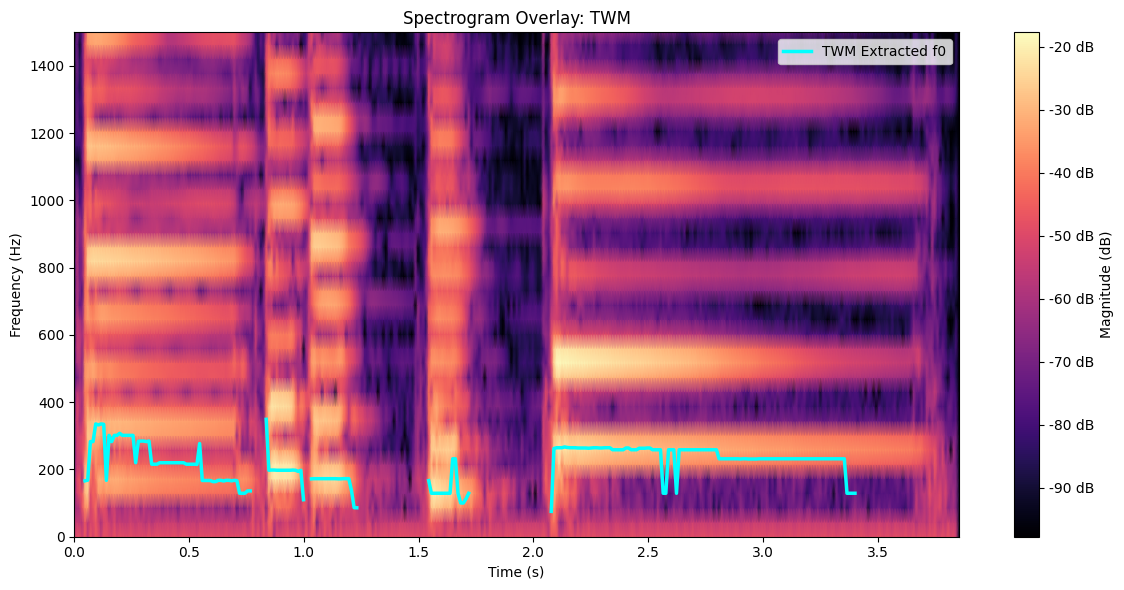

In [8]:
Zxx_dB = 20 * np.log10(np.maximum(Zxx_mag, 1e-10))

pitch_contour_plot = np.where(pitch_contour == 0, np.nan, pitch_contour)

plt.figure(figsize=(12, 6))

vmax = np.max(Zxx_dB)
plt.pcolormesh(t, f, Zxx_dB, shading='gouraud', cmap='magma', vmin=vmax - 80, vmax=vmax)
plt.colorbar(format='%+2.0f dB', label='Magnitude (dB)')

plt.plot(t, pitch_contour_plot, color='cyan', linewidth=2.5, label='TWM Extracted f0')


plt.ylim(0, 1500)
plt.xlim(t[0], t[-1])

plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram Overlay: TWM')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## what slightly improved the model
- changing signal.find_peaks() height => height + prominence
- masking the range($50<f_k < 4000$): somewhere improved somewhere got noisy
- increase kernel_size on scipy.signal.medfilt
- keep candidates that could explain the lowest strong peak
- at least 3 harmonics must fit below threshhold

## Previous YIN was significantly better
- TWM consistently drops out.
- The higher harmonics die off first which leaves mostly just the fundamental -> YIN tracks this well, but TWM requires multiple peaks to calculate, leading to no result.
- Struggled on the transition between notes

## Prospect
Time-Domain Algorithm are going to beat naive frequency-domain algo(TWM) for pure monophonic pitch tracking on real signal.

**Looking forward to TWM to shine on polyphonic analysis.**